In [1]:
import sys
from pathlib import Path
import os
sys.path.append(str(Path.cwd().parent))
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch

from src.model import UNet


device = torch.device("mps")

model = UNet().to(device)

model.load_state_dict(
    torch.load(
        "../models/epoch20_best_model.pt",
        map_location=device,
    )
)

model.eval()

""

''

In [9]:
def predict(model, image, device, threshold=0.5):
    model.eval()

    with torch.no_grad():
        image = image.unsqueeze(0).to(device)

        logits = model(image)

        probability = torch.sigmoid(logits)

        prediction = probability >= threshold

    return (
        probability.squeeze().cpu().numpy(),
        prediction.squeeze().cpu().numpy(),
    )

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from src.dataset import OilSpillDataset
import random

val_dataset = OilSpillDataset(
    image_dir="../data/images/val",
    mask_dir="../data/masks/val",
)

In [33]:
index = random.randint(0, len(val_dataset)-1)

image, ground_truth = val_dataset[index]

print("looking at validation image at index: ", index)

looking at validation image at index:  1417


In [34]:
from src.polygon import mask_to_polygons

probability, prediction = predict(
    model,
    image,
    device,
)

regions = mask_to_polygons(
    prediction,
    min_area=20,
)

print("regions:", len(regions))

for i, region in enumerate(regions):

    print(
        f"region {i}: "
        f"area={region['area']:.1f}, "
        f"vertices={len(region['polygon'])}, "
        f"bbox={region['bbox']}"
    )

regions: 5
region 0: area=15566.0, vertices=124, bbox=(0, 0, 152, 256)
region 1: area=299.0, vertices=44, bbox=(237, 70, 19, 30)
region 2: area=86.0, vertices=31, bbox=(151, 193, 15, 22)
region 3: area=83.5, vertices=20, bbox=(0, 20, 9, 14)
region 4: area=23.5, vertices=14, bbox=(123, 167, 7, 7)


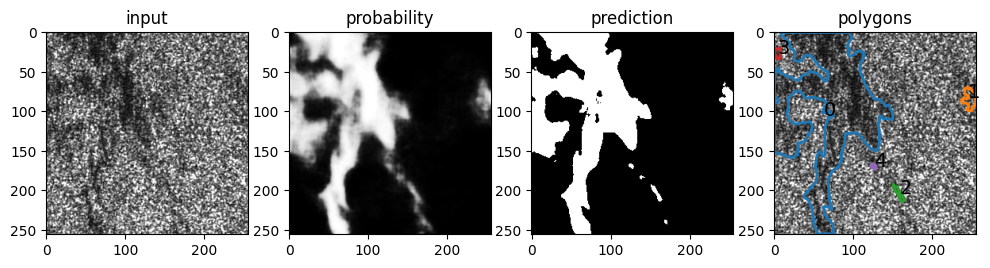

In [35]:
fig, axes = plt.subplots(
    1,
    4,
    figsize=(12, 12),
)

axes[0].imshow(image.squeeze(), cmap="gray")
axes[0].set_title("input")

axes[1].imshow(probability, cmap="gray")
axes[1].set_title("probability")

axes[2].imshow(prediction, cmap="gray")
axes[2].set_title("prediction")

axes[3].imshow(image.squeeze(), cmap="gray")
axes[3].set_title("polygons")

for i, region in enumerate(regions):
    polygon = region["polygon"]

    closed = np.vstack([
        polygon,
        polygon[0],
    ])

    axes[3].plot(
        closed[:, 0],
        closed[:, 1],
        linewidth=2,
    )

    centroid = polygon.mean(axis=0)

    axes[3].text(
        centroid[0],
        centroid[1],
        str(i),
        fontsize=14,
    )

plt.show()

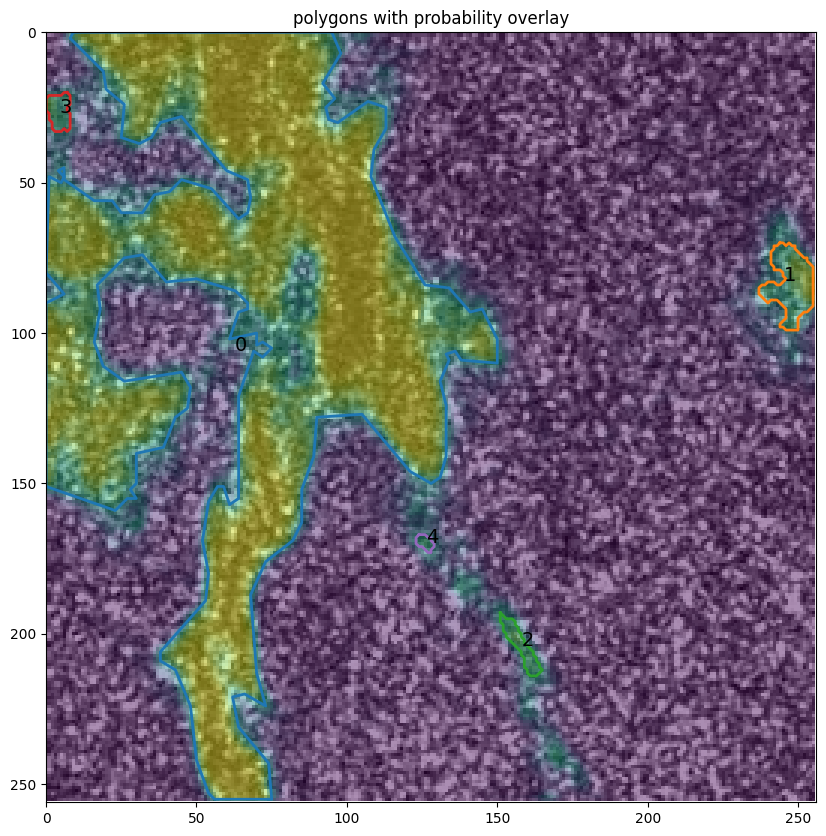

In [36]:
plt.figure(figsize=(10, 10))

plt.imshow(
    image.squeeze(),
    cmap="gray",
)
plt.imshow(
    probability,
    alpha=0.45,
)

for i, region in enumerate(regions):

    polygon = region["polygon"]

    closed = np.vstack([
        polygon,
        polygon[0],
    ])

    plt.plot(
        closed[:, 0],
        closed[:, 1],
        linewidth=2,
    )

    centroid = polygon.mean(axis=0)

    plt.text(
        centroid[0],
        centroid[1],
        str(i),
        fontsize=14,
    )

plt.xlim(0, 256)
plt.ylim(256, 0)


plt.title("polygons with probability overlay")

plt.show()